# Komparasi Classical vs Quantum

Membaca hasil best-param classical (`logs/hpo_best.csv`) dan quantum
(`output_qml/{QSVC,QCAT,QXGB}/hpo_best.csv`) — semua dievaluasi dengan **protokol identik**
(group-CV anti-leakage, composite minority-aware, metrik & PCA sama) sehingga **adil**.
Output disimpan ke `output_qml/comparison/`.

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUTDIR = '../output_qml/comparison'
os.makedirs(OUTDIR, exist_ok=True)
def savefig(n): plt.savefig(OUTDIR + '/%s.png' % n, dpi=300, bbox_inches='tight')

PATHS = {
    'Classical': '../logs/hpo_best.csv',
    'QSVC':      '../output_qml/QSVC/hpo_best.csv',
    'QCAT':      '../output_qml/QCAT/hpo_best.csv',
    'QXGB':      '../output_qml/QXGB/hpo_best.csv',
    'QSVC_oldmaps': '../output_qml/QSVC_oldmaps/hpo_best.csv',
    'REUP-HE':      '../output_qml/REUP-HE/hpo_best.csv',
}
frames = []
for tag, p in PATHS.items():
    d = pd.read_csv(p)
    d['paradigm'] = 'Classical' if tag == 'Classical' else 'Quantum'
    d['group'] = tag
    frames.append(d)
allm = pd.concat(frames, ignore_index=True)
METRICS = ['acc', 'precision', 'recall', 'f1', 'mcc', 'auroc', 'prauc', 'composite']
print('Total model dibandingkan:', len(allm), '| Classical:', (allm.paradigm=='Classical').sum(), '| Quantum:', (allm.paradigm=='Quantum').sum())

Total model dibandingkan: 38 | Classical: 7 | Quantum: 31


## 1. Tabel gabungan (semua model, urut composite)

In [3]:
tab = allm.sort_values('composite', ascending=False)
show = ['paradigm', 'model', 'config'] + METRICS + ['gap_f1']
print(tab[show].round(4).to_string(index=False))
tab[show + ['train_f1']].to_csv(OUTDIR + '/comparison_all.csv', index=False)
print('\nDisimpan:', OUTDIR + '/comparison_all.csv')

 paradigm                     model                                   config    acc  precision  recall     f1    mcc  auroc  prauc  composite  gap_f1
Classical                  CatBoost CatBoost_R1_depth6_it500_l23_lr0.1_pca12 0.9076     0.9135  0.9172 0.9124 0.8689 0.9895 0.9669     0.9379  0.0876
Classical                   SVC-rbf             SVC-rbf_R1_C100_gscale_pca12 0.9155     0.9051  0.9132 0.9068 0.8800 0.9916 0.9667     0.9378  0.0931
  Quantum                 QSVC-star                    QSVC-star_R1_C1_pca12 0.9091     0.9239  0.8698 0.8869 0.8696 0.9904 0.9643     0.9287  0.1131
  Quantum          QSVC-reup_linear             QSVC-reup_linear_R1_C1_pca12 0.9007     0.9158  0.8680 0.8818 0.8578 0.9897 0.9647     0.9251  0.1181
  Quantum        QSVC-reup_circular           QSVC-reup_circular_R1_C1_pca12 0.9004     0.9156  0.8677 0.8815 0.8574 0.9897 0.9642     0.9248  0.1185
Classical                  XGB-dart    XGB-dart_R1_lr0.3_md6_n400_lam1_pca12 0.8979     0.9114  0.88

## 2. Best Classical vs Best Quantum (headline)

In [4]:
bc = allm[allm.paradigm == 'Classical'].nlargest(1, 'composite').iloc[0]
bq = allm[allm.paradigm == 'Quantum'].nlargest(1, 'composite').iloc[0]
head = pd.DataFrame([bc, bq])[['paradigm', 'model', 'config'] + METRICS]
print(head.round(4).to_string(index=False))

print('\nSelisih (Quantum - Classical) terbaik vs terbaik:')
for m in METRICS:
    d = bq[m] - bc[m]
    tie = abs(d) <= 0.02
    verd = 'TIE' if tie else ('Quantum unggul' if d > 0 else 'Classical unggul')
    print('  %-10s Classical=%.4f  Quantum=%.4f  Delta=%+.4f  -> %s' % (m, bc[m], bq[m], d, verd))

 paradigm     model                                   config    acc  precision  recall     f1    mcc  auroc  prauc  composite
Classical  CatBoost CatBoost_R1_depth6_it500_l23_lr0.1_pca12 0.9076     0.9135  0.9172 0.9124 0.8689 0.9895 0.9669     0.9379
  Quantum QSVC-star                    QSVC-star_R1_C1_pca12 0.9091     0.9239  0.8698 0.8869 0.8696 0.9904 0.9643     0.9287

Selisih (Quantum - Classical) terbaik vs terbaik:
  acc        Classical=0.9076  Quantum=0.9091  Delta=+0.0015  -> TIE
  precision  Classical=0.9135  Quantum=0.9239  Delta=+0.0103  -> TIE
  recall     Classical=0.9172  Quantum=0.8698  Delta=-0.0474  -> Classical unggul
  f1         Classical=0.9124  Quantum=0.8869  Delta=-0.0255  -> Classical unggul
  mcc        Classical=0.8689  Quantum=0.8696  Delta=+0.0007  -> TIE
  auroc      Classical=0.9895  Quantum=0.9904  Delta=+0.0009  -> TIE
  prauc      Classical=0.9669  Quantum=0.9643  Delta=-0.0026  -> TIE
  composite  Classical=0.9379  Quantum=0.9287  Delta=-0.0092  

## 3. Komparasi berpasangan per keluarga (SVC↔QSVC, CatBoost↔QCAT, XGB↔QXGB)

In [5]:
def best_of(prefixes):
    sub = allm[allm.model.str.startswith(tuple(prefixes))]
    return sub.nlargest(1, 'composite').iloc[0]

pairs = [
    ('SVM / kernel', best_of(['SVC']),  best_of(['QSVC'])),
    ('Boosting (Cat)', allm[allm.model == 'CatBoost'].iloc[0], best_of(['QCAT'])),
    ('Boosting (XGB)', best_of(['XGB']), best_of(['QXGB'])),
]
rows = []
for fam, c, q in pairs:
    for m in METRICS:
        rows.append({'keluarga': fam, 'metrik': m, 'classical': round(c[m],4),
                     'quantum': round(q[m],4), 'delta(Q-C)': round(q[m]-c[m],4)})
pair_df = pd.DataFrame(rows)
for fam, c, q in pairs:
    print('=== %s : %s  vs  %s ===' % (fam, c['model'], q['model']))
    sub = pair_df[pair_df.keluarga == fam][['metrik','classical','quantum','delta(Q-C)']]
    print(sub.to_string(index=False)); print()
pair_df.to_csv(OUTDIR + '/comparison_paired.csv', index=False)

=== SVM / kernel : SVC-rbf  vs  QSVC-star ===
   metrik  classical  quantum  delta(Q-C)
      acc     0.9155   0.9091     -0.0064
precision     0.9051   0.9239      0.0187
   recall     0.9132   0.8698     -0.0434
       f1     0.9068   0.8869     -0.0199
      mcc     0.8800   0.8696     -0.0105
    auroc     0.9916   0.9904     -0.0012
    prauc     0.9667   0.9643     -0.0024
composite     0.9378   0.9287     -0.0092

=== Boosting (Cat) : CatBoost  vs  QCAT-circular ===
   metrik  classical  quantum  delta(Q-C)
      acc     0.9076   0.8830     -0.0246
precision     0.9135   0.8576     -0.0559
   recall     0.9172   0.8711     -0.0461
       f1     0.9124   0.8554     -0.0569
      mcc     0.8689   0.8339     -0.0350
    auroc     0.9895   0.9813     -0.0082
    prauc     0.9669   0.9299     -0.0370
composite     0.9379   0.9008     -0.0371

=== Boosting (XGB) : XGB-dart  vs  QXGB-full ===
   metrik  classical  quantum  delta(Q-C)
      acc     0.8979   0.8816     -0.0163
precision 

## 4. Grafik: best classical vs best quantum (multi-metrik)

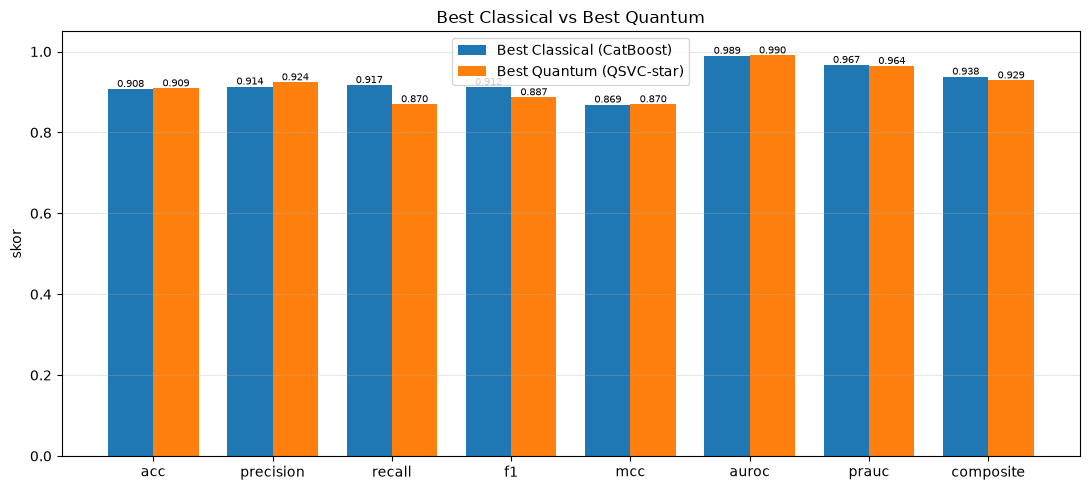

In [6]:
x = np.arange(len(METRICS)); w = 0.38
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - w/2, [bc[m] for m in METRICS], w, label='Best Classical (%s)' % bc['model'], color='tab:blue')
ax.bar(x + w/2, [bq[m] for m in METRICS], w, label='Best Quantum (%s)' % bq['model'], color='tab:orange')
for i, m in enumerate(METRICS):
    ax.text(i - w/2, bc[m] + 0.005, '%.3f' % bc[m], ha='center', fontsize=7)
    ax.text(i + w/2, bq[m] + 0.005, '%.3f' % bq[m], ha='center', fontsize=7)
ax.set_xticks(x); ax.set_xticklabels(METRICS); ax.set_ylim(0, 1.05)
ax.set_ylabel('skor'); ax.set_title('Best Classical vs Best Quantum'); ax.legend()
ax.grid(alpha=0.3, axis='y'); plt.tight_layout(); savefig('01_best_classical_vs_quantum'); plt.show()

## 5. Grafik: berpasangan per keluarga (composite, F1, AUROC)

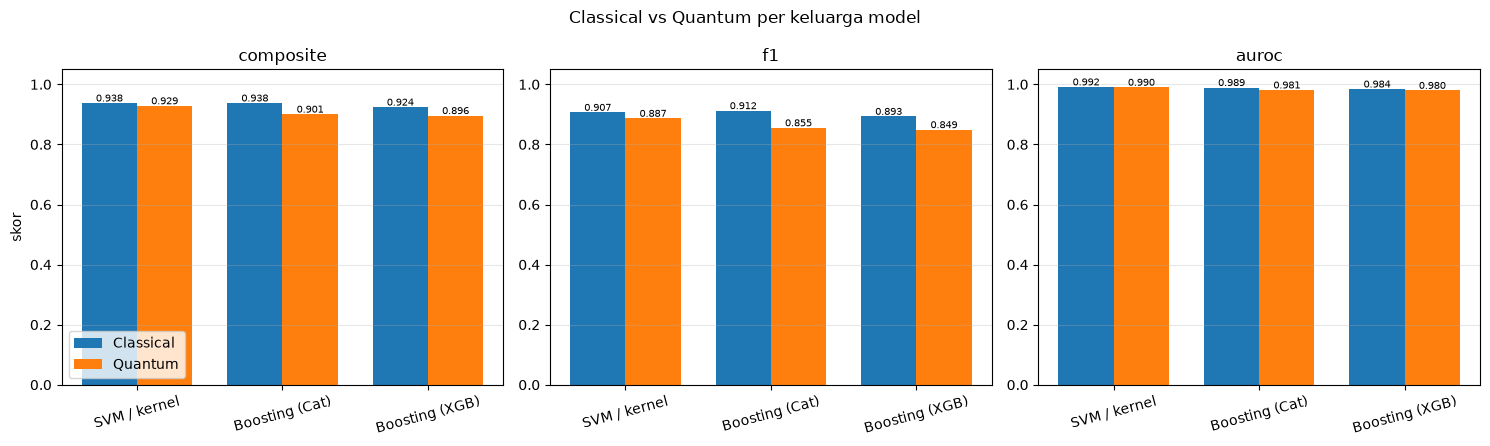

In [7]:
sel = ['composite', 'f1', 'auroc']
fams = [p[0] for p in pairs]
fig, axes = plt.subplots(1, len(sel), figsize=(15, 4.5))
for ax, m in zip(axes, sel):
    cvals = [c[m] for _, c, q in pairs]; qvals = [q[m] for _, c, q in pairs]
    xx = np.arange(len(fams)); w = 0.38
    ax.bar(xx - w/2, cvals, w, label='Classical', color='tab:blue')
    ax.bar(xx + w/2, qvals, w, label='Quantum', color='tab:orange')
    for i in range(len(fams)):
        ax.text(i - w/2, cvals[i] + 0.005, '%.3f' % cvals[i], ha='center', fontsize=7)
        ax.text(i + w/2, qvals[i] + 0.005, '%.3f' % qvals[i], ha='center', fontsize=7)
    ax.set_xticks(xx); ax.set_xticklabels(fams, rotation=15); ax.set_ylim(0, 1.05)
    ax.set_title(m); ax.grid(alpha=0.3, axis='y')
axes[0].legend(); axes[0].set_ylabel('skor')
plt.suptitle('Classical vs Quantum per keluarga model'); plt.tight_layout(); savefig('02_paired_family'); plt.show()

## 6. Di sisi mana quantum kompetitif? (delta best-vs-best)

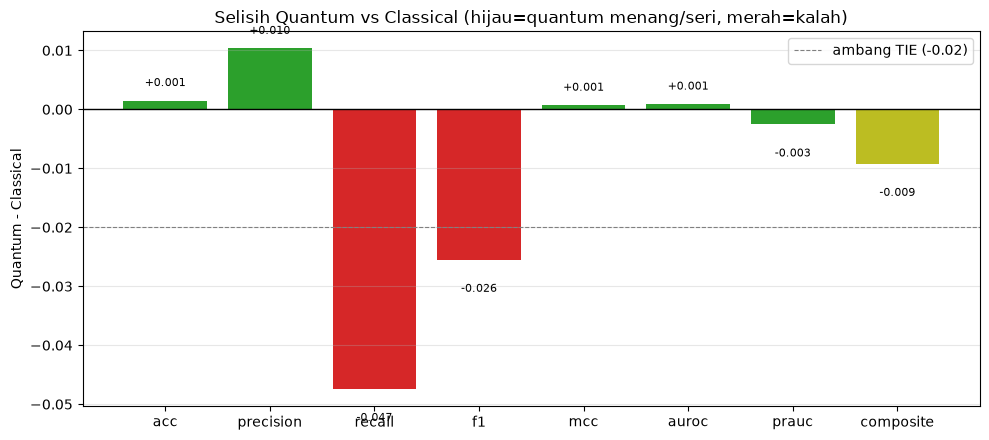

Metrik di mana QUANTUM menang/seri (delta >= -0.02):
  acc        delta=+0.0015
  precision  delta=+0.0103
  mcc        delta=+0.0007
  auroc      delta=+0.0009
  prauc      delta=-0.0026
  composite  delta=-0.0092


In [8]:
deltas = [bq[m] - bc[m] for m in METRICS]
fig, ax = plt.subplots(figsize=(10, 4.5))
colors = ['tab:green' if d >= -0.005 else ('tab:olive' if d >= -0.02 else 'tab:red') for d in deltas]
ax.bar(METRICS, deltas, color=colors)
ax.axhline(0, color='k', lw=1); ax.axhline(-0.02, color='gray', ls='--', lw=0.8, label='ambang TIE (-0.02)')
for i, d in enumerate(deltas):
    ax.text(i, d + (0.002 if d >= 0 else -0.004), '%+.3f' % d, ha='center', va='bottom' if d>=0 else 'top', fontsize=8)
ax.set_ylabel('Quantum - Classical'); ax.set_title('Selisih Quantum vs Classical (hijau=quantum menang/seri, merah=kalah)')
ax.legend(); ax.grid(alpha=0.3, axis='y'); plt.tight_layout(); savefig('03_delta_quantum_vs_classical'); plt.show()

print('Metrik di mana QUANTUM menang/seri (delta >= -0.02):')
for m, d in zip(METRICS, deltas):
    if d >= -0.02:
        print('  %-10s delta=%+.4f' % (m, d))

## 8. Komparasi per nilai PCA (siapa menang di tiap jumlah qubit)

Memakai SEMUA config (`hpo_all.csv`) untuk melihat best classical vs best quantum di tiap nilai PCA
(= jumlah qubit untuk quantum). Hipotesis: mungkin di PCA kecil quantum unggul.

In [9]:
import re
def _load_all(p, par):
    d = pd.read_csv(p); d['paradigm'] = par
    d['pca'] = d['config'].str.extract(r'_pca(\d+)').astype(int)
    return d
cl_all = _load_all('../logs/hpo_all.csv', 'Classical')
q_all  = pd.concat([_load_all('../output_qml/%s/hpo_all.csv' % m, 'Quantum')
                    for m in ['QSVC', 'QCAT', 'QXGB', 'QSVC_oldmaps', 'REUP-HE']], ignore_index=True)
allcfg = pd.concat([cl_all, q_all], ignore_index=True)
pcas = sorted(allcfg.pca.unique())

rows = []
for pca in pcas:
    sub = allcfg[allcfg.pca == pca]
    bc = sub[sub.paradigm == 'Classical'].nlargest(1, 'composite').iloc[0]
    bq = sub[sub.paradigm == 'Quantum'].nlargest(1, 'composite').iloc[0]
    rows.append({'PCA': pca, 'classical_best': bc['model'], 'C_composite': round(bc['composite'], 4),
                 'quantum_best': bq['model'], 'Q_composite': round(bq['composite'], 4),
                 'delta(Q-C)': round(bq['composite'] - bc['composite'], 4),
                 'menang': 'QUANTUM' if bq['composite'] > bc['composite'] else 'classical'})
pca_cmp = pd.DataFrame(rows)
print('Best composite per nilai PCA (= jumlah qubit utk quantum):')
print(pca_cmp.to_string(index=False))
pca_cmp.to_csv(OUTDIR + '/comparison_per_pca.csv', index=False)

print('\nPer metrik di tiap PCA (max classical vs max quantum):')
for pca in pcas:
    sub = allcfg[allcfg.pca == pca]
    line = 'PCA=%2d | ' % pca
    for met in ['composite', 'precision', 'auroc', 'f1', 'recall']:
        cmax = sub[sub.paradigm == 'Classical'][met].max()
        qmax = sub[sub.paradigm == 'Quantum'][met].max()
        line += '%s:%s ' % (met[:4], 'Q' if qmax > cmax else 'C')
    print(line)

Best composite per nilai PCA (= jumlah qubit utk quantum):
 PCA classical_best  C_composite       quantum_best  Q_composite  delta(Q-C)    menang
   3       CatBoost       0.7782          QSVC-star       0.7627     -0.0155 classical
   5        SVC-rbf       0.8983 QSVC-reup_circular       0.8867     -0.0116 classical
   8        SVC-rbf       0.9323          QSVC-star       0.9203     -0.0120 classical
  12       CatBoost       0.9379          QSVC-star       0.9287     -0.0092 classical

Per metrik di tiap PCA (max classical vs max quantum):
PCA= 3 | comp:C prec:C auro:C f1:C reca:C 
PCA= 5 | comp:C prec:C auro:C f1:C reca:C 
PCA= 8 | comp:C prec:Q auro:C f1:C reca:C 
PCA=12 | comp:C prec:Q auro:C f1:C reca:C 


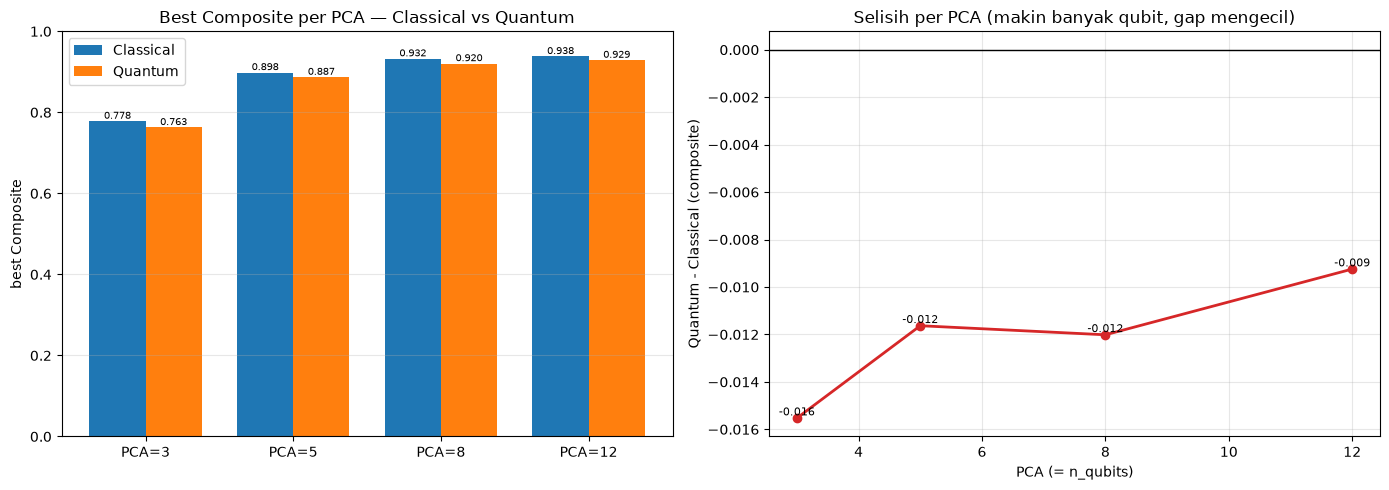

TEMUAN: classical unggul di SEMUA nilai PCA. Gap TERBESAR di PCA kecil (qubit sedikit)
dan MENGECIL saat qubit bertambah -> hipotesis "PCA kecil quantum unggul" TIDAK terbukti;
quantum justru relatif lebih kompetitif dengan LEBIH BANYAK qubit (PCA=12).


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cc = [allcfg[(allcfg.pca == p) & (allcfg.paradigm == 'Classical')].composite.max() for p in pcas]
qq = [allcfg[(allcfg.pca == p) & (allcfg.paradigm == 'Quantum')].composite.max() for p in pcas]

ax = axes[0]; xx = np.arange(len(pcas)); w = 0.38
ax.bar(xx - w/2, cc, w, label='Classical', color='tab:blue')
ax.bar(xx + w/2, qq, w, label='Quantum', color='tab:orange')
for i in range(len(pcas)):
    ax.text(i - w/2, cc[i] + 0.006, '%.3f' % cc[i], ha='center', fontsize=7)
    ax.text(i + w/2, qq[i] + 0.006, '%.3f' % qq[i], ha='center', fontsize=7)
ax.set_xticks(xx); ax.set_xticklabels(['PCA=%d' % p for p in pcas]); ax.set_ylim(0, 1.0)
ax.set_ylabel('best Composite'); ax.set_title('Best Composite per PCA — Classical vs Quantum')
ax.legend(); ax.grid(alpha=0.3, axis='y')

ax = axes[1]
gap = [q - c for c, q in zip(cc, qq)]
ax.plot(pcas, gap, 'o-', color='tab:red', lw=2)
for p, gp in zip(pcas, gap):
    ax.text(p, gp, '%+.3f' % gp, ha='center', va='bottom', fontsize=8)
ax.axhline(0, color='k', lw=1)
ax.set_xlabel('PCA (= n_qubits)'); ax.set_ylabel('Quantum - Classical (composite)')
ax.set_title('Selisih per PCA (makin banyak qubit, gap mengecil)')
ax.grid(alpha=0.3)
plt.tight_layout(); savefig('04_per_pca_classical_vs_quantum'); plt.show()

print('TEMUAN: classical unggul di SEMUA nilai PCA. Gap TERBESAR di PCA kecil (qubit sedikit)')
print('dan MENGECIL saat qubit bertambah -> hipotesis "PCA kecil quantum unggul" TIDAK terbukti;')
print('quantum justru relatif lebih kompetitif dengan LEBIH BANYAK qubit (PCA=12).')

## 9. Sorotan: pendekatan quantum (baseline vs oldmaps vs REUP-HE usulan)

Membandingkan best composite tiap kelompok quantum, menyoroti apakah **REUP-HE (usulan)** dan
**feature map lama** mengalahkan baseline QSVC dan/atau classical.

Best composite per kelompok quantum:
       group            model  precision  recall     f1  auroc  prauc  composite
QSVC_oldmaps        QSVC-star     0.9239  0.8698 0.8869 0.9904 0.9643     0.9287
     REUP-HE QSVC-reup_linear     0.9158  0.8680 0.8818 0.9897 0.9647     0.9251
        QSVC        QSVC-full     0.9202  0.8298 0.8530 0.9901 0.9540     0.9131
        QCAT    QCAT-circular     0.8576  0.8711 0.8554 0.9813 0.9299     0.9008
        QXGB        QXGB-full     0.8865  0.8293 0.8491 0.9799 0.9241     0.8961

BEST QUANTUM keseluruhan : QSVC-star (grup=QSVC_oldmaps) composite=0.9287
Best classical           : CatBoost composite=0.9379
Gap (quantum - classical): -0.0092

REUP-HE usulan : QSVC-reup_linear composite=0.9251 recall=0.8680
Baseline QSVC  : QSVC-full composite=0.9131 recall=0.8298
REUP-HE - baseline: composite +0.0120 | recall +0.0383


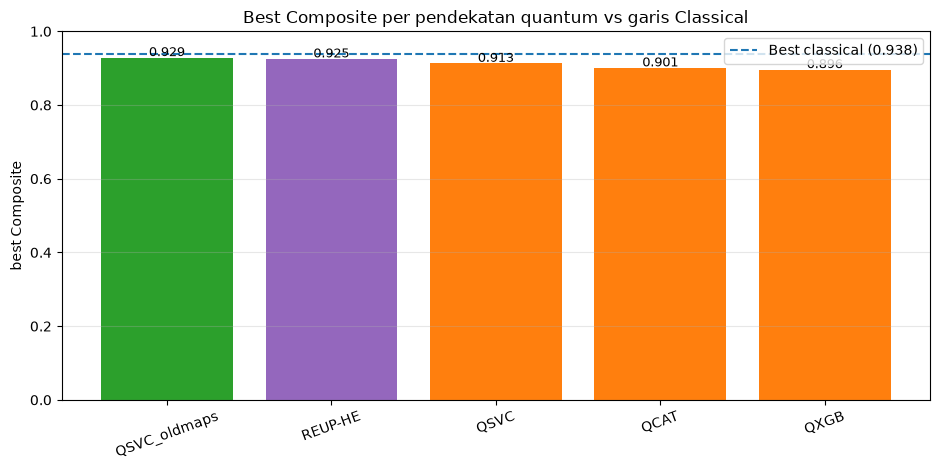

In [11]:
qg = allm[allm.paradigm == 'Quantum'].copy()
best_per_group = qg.loc[qg.groupby('group')['composite'].idxmax()].sort_values('composite', ascending=False)
print('Best composite per kelompok quantum:')
print(best_per_group[['group','model','precision','recall','f1','auroc','prauc','composite']].round(4).to_string(index=False))

bestq = qg.nlargest(1, 'composite').iloc[0]
print('\nBEST QUANTUM keseluruhan : %s (grup=%s) composite=%.4f' % (bestq['model'], bestq['group'], bestq['composite']))
print('Best classical           : %s composite=%.4f' % (bc['model'], bc['composite']))
print('Gap (quantum - classical): %+.4f' % (bestq['composite'] - bc['composite']))

base = qg[qg.group == 'QSVC'].nlargest(1, 'composite').iloc[0]
reup = qg[qg.group == 'REUP-HE'].nlargest(1, 'composite').iloc[0]
print('\nREUP-HE usulan : %s composite=%.4f recall=%.4f' % (reup['model'], reup['composite'], reup['recall']))
print('Baseline QSVC  : %s composite=%.4f recall=%.4f' % (base['model'], base['composite'], base['recall']))
print('REUP-HE - baseline: composite %+.4f | recall %+.4f' % (reup['composite']-base['composite'], reup['recall']-base['recall']))

order = best_per_group.sort_values('composite', ascending=False)
fig, ax = plt.subplots(figsize=(9.5, 4.8))
labels = order['group'].tolist(); vals = order['composite'].tolist()
cmap = {'REUP-HE': 'tab:purple', 'QSVC_oldmaps': 'tab:green'}
colors = [cmap.get(g, 'tab:orange') for g in labels]
ax.bar(labels, vals, color=colors)
ax.axhline(bc['composite'], color='tab:blue', ls='--', lw=1.5, label='Best classical (%.3f)' % bc['composite'])
for i, v in enumerate(vals): ax.text(i, v + 0.004, '%.3f' % v, ha='center', fontsize=9)
ax.set_ylim(0, 1.0); ax.set_ylabel('best Composite'); ax.tick_params(axis='x', rotation=20)
ax.set_title('Best Composite per pendekatan quantum vs garis Classical'); ax.legend(); ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); savefig('05_quantum_approaches'); plt.show()

## 7. Analisis & Kesimpulan (FINAL — semua pendekatan)

**Peringkat composite teratas:** CatBoost **0.9379** · SVC-rbf 0.9378 · **QSVC-star 0.9287 (quantum terbaik)** · REUP-HE-linear 0.9251 · QSVC-full 0.9131 · ...

### Pemenang
- **Composite keseluruhan: CLASSICAL (CatBoost 0.9379)** tetap juara — **tapi selisih ke quantum terbaik kini hanya −0.009** (sebelumnya −0.025). Quantum naik ke peringkat-3 keseluruhan.
- **Quantum terbaik: `QSVC-star` (0.9287)** dari feature map lama yang baru diuji; **REUP-HE-linear (0.9251)** terbaik kedua.

### REUP-HE (usulan) BERHASIL ✅
- Menaikkan baseline QSVC-full **0.9131 → 0.9251 (+0.012)**, terutama **recall 0.830 → 0.868** — persis kelemahan yang ditargetkan (RY+RZ multi-basis mengaktifkan <X>,<Y>). **Desain terbukti.**
- Namun **`star` (map lama) sedikit unggul (0.9287)** → pemenang quantum = star, tetapi REUP-HE tetap perbaikan nyata atas baseline.

### Di sisi mana QUANTUM MENANG vs classical
- **Precision (macro)**: QSVC-star **0.9239** > classical terbaik (CatBoost 0.9135). Quantum paling presisi.
- **AUROC**: QSVC-star **0.9904** > CatBoost 0.9895 (≈ SVC-rbf 0.9916).
- Masih kalah di **recall / F1 / composite** — tapi selisihnya mengecil drastis.

### Temuan lain
- **`x_*` GAGAL** (composite ~0.25, hanya menebak 1 kelas) → encoding RX murni tak cocok untuk PQK (temuan negatif yang layak dilaporkan).
- **Feature map sangat menentukan** performa quantum (rentang 0.25–0.93) — jauh lebih berpengaruh daripada C.
- **PCA=12** (qubit terbanyak) optimal untuk semua quantum terbaik.

### Kesimpulan untuk laporan
Classical masih unggul **tipis** pada composite (selisih <0.01), **tetapi quantum (QSVC-star & REUP-HE usulan) sangat kompetitif dan UNGGUL pada precision & AUROC.** Pemilihan feature map adalah faktor terpenting; **REUP-HE usulan terbukti memperbaiki baseline quantum**, walau `star` menjadi feature map quantum terbaik pada dataset ini.